# 1. Set up

In [1]:
!pip install pandas
!pip install scikit-learn
!pip install pyarrow
!pip install torch
!pip install lightgbm category_encoders scikit-plot
!pip install pyproj
!pip install seaborn

# 2. Import necessary libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV

import torch.nn as nn

import category_encoders as ce
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve,confusion_matrix, classification_report, precision_recall_curve, auc, recall_score, precision_score,
    f1_score
)
from pyproj import Transformer
import shap
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression

from utils import *

c:\Users\GAZARAGOZAG-local\Documents\UFD\Repo_2\ufd-dataia-deteccion-fraude\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 3. Define global variables

we will be using march as the training month and april as the validation month

In [3]:
INPUT_X_PATH = "../data/output_data/data_training_march.csv"
INPUT_X_EVAL_PATH = "../data/output_data/data_validation_april.csv"
INPUT_Y_EVAL_PATH = "../data/output_data/data_validation_april_y.csv"
INPUT_Y_PATH = "../data/output_data/data_training_april_y.csv"

INPUT_FINAL_DF_PATH  = "../data/output_data/final_df_non_supervised_march.csv"
INPUT_FINAL_DF_EVAL_PATH  = "../data/output_data/final_df_eval_non_supervised_march.csv"

In [4]:
OUTPUT_FEATURE_IMPORTANCE_LOGREG = "../powerbi/feature_importance_logreg.csv"

In [5]:
train_losses = list()
target_col = "target"

Let's define some colors for the viz we will be doing

In [6]:
ufd_orange = "#f26122"
ufd_blue = "#003865"
ufd_gray = "#cccccc"

# 4. Functions

# 5. Code

## 5.1. Data loading

We will load the data, both the training and the validation data

In [7]:
X = pd.read_csv(INPUT_X_PATH, sep=";")
y = pd.read_csv(INPUT_Y_PATH, sep=";")[target_col]
X_eval = pd.read_csv(INPUT_X_EVAL_PATH, sep=";")
y_eval = pd.read_csv(INPUT_Y_EVAL_PATH, sep=";")[target_col]

final_df = pd.read_csv(INPUT_FINAL_DF_PATH, sep=";")
final_df_eval = pd.read_csv(INPUT_FINAL_DF_EVAL_PATH, sep=";")

In [8]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in ['cups_sgc', 'cnt_id', target_col]]

## 5.2. Supervised learning

In [9]:
X.fillna(0, inplace=True)
y.fillna(0, inplace=True)

X_eval.fillna(0, inplace=True)
y_eval.fillna(0, inplace=True) 

### 5.2.1. Modelling

Primero de todo extraemos el train test split

Realizamos un target encoding a aquellas variables que sean categóricas en nuestro dato:

In [10]:
encoder = ce.TargetEncoder(cols=cat_cols)
X_train_enc = encoder.fit_transform(X, y)

Finalmente definimos el modelo y lo entrenamos

In [11]:
model = LogisticRegression(
     random_state=42,
     max_iter=100,
 )

model.fit(X_train_enc, y)


c:\Users\GAZARAGOZAG-local\Documents\UFD\Repo_2\ufd-dataia-deteccion-fraude\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### 5.2.2. Metrics extraction

Para poder calcular las métricas, en primer lugar debemos calcular las predicciones

In [12]:
y_proba = model.predict_proba(X_train_enc)[:, 1] 
y_pred = model.predict(X_train_enc)

Primeramente pintaremos la curva ROC junto con su valor de AUC

In [13]:
auc_df = compute_individual_auc(X, y, target_col="target")

print(auc_df.head(15))

Computing AUCs: 100%|██████████| 75/75 [00:00<00:00, 193.68it/s]

                                              feature       auc
0                            consumo_zero_anio_actual  0.780383
1                          consumo_zero_anio_anterior  0.761920
2                       consumo_zero_trimestre_actual  0.713074
3                       consumo_zero_trimestre_pasado  0.703118
4                  consumo_zero_trimestre_anio_pasado  0.696510
5                             consumo_zero_mes_actual  0.680857
6                             consumo_zero_mes_pasado  0.675144
7                        consumo_zero_mes_anio_pasado  0.666638
8                          consumo_zero_semana_actual  0.663087
9                          consumo_zero_semana_pasada  0.659768
10                    consumo_zero_semana_anio_pasado  0.648869
11  porcentaje_calidad_datos_trimestre_pasado_corr...  0.627765
12   porcentaje_calidad_datos_semana_pasada_correctos  0.614982
13      porcentaje_calidad_datos_mes_pasado_correctos  0.612326
14                        consumo_count_

In [14]:
auc_df = compute_individual_auc(X_eval, y_eval, target_col="target")

print(auc_df.head(15))

Computing AUCs: 100%|██████████| 75/75 [00:00<00:00, 212.15it/s]

                                              feature       auc
0                            consumo_zero_anio_actual  0.790526
1                          consumo_zero_anio_anterior  0.757931
2                       consumo_zero_trimestre_pasado  0.701434
3                       consumo_zero_trimestre_actual  0.699913
4                             consumo_zero_mes_actual  0.699913
5                          consumo_zero_semana_actual  0.683181
6                             consumo_zero_mes_pasado  0.671230
7                        consumo_zero_mes_anio_pasado  0.663407
8                  consumo_zero_trimestre_anio_pasado  0.663407
9                          consumo_zero_semana_pasada  0.659713
10                    consumo_zero_semana_anio_pasado  0.644937
11  porcentaje_calidad_datos_mismo_mes_anio_pasado...  0.640051
12  porcentaje_calidad_datos_mismo_trimestre_anio_...  0.640051
13  porcentaje_calidad_datos_trimestre_actual_corr...  0.631000
14      porcentaje_calidad_datos_mes_act

In [15]:
final_df["target"].value_counts(normalize=True)

target
0.0    0.939613
1.0    0.060387
Name: proportion, dtype: float64

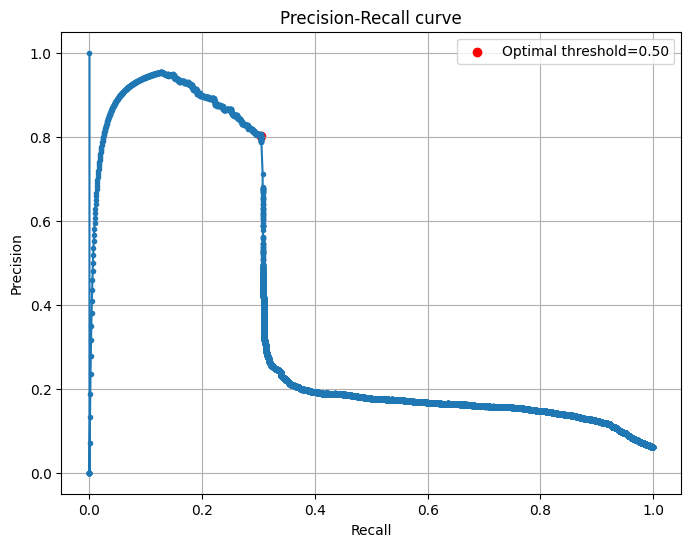

In [16]:
thres_train, _ = find_optimal_thres(y, y_proba)

### 5.2.3. Predictions calibration

In [17]:
calibrated_model = CalibratedClassifierCV(estimator=model,
                                          method="isotonic", cv=5)
calibrated_model.fit(X, y)

proba_cal_val = calibrated_model.predict_proba(X_eval)[:,1]

c:\Users\GAZARAGOZAG-local\Documents\UFD\Repo_2\ufd-dataia-deteccion-fraude\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\GAZARAGOZAG-local\Documents\UFD\Repo_2\ufd-dataia-deteccion-fraude\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also

In [18]:
# ejemplo de costes
C_FN = 1000  # coste de dejar pasar un fraude
C_FP = 50    # coste de investigar un inocente

best_cost, best_thr, FN, FP = find_cost_optimal_threshold(y_eval, proba_cal_val, C_FN, C_FP)
print(f"Umbral coste-óptimo: {best_thr:.3f} (Coste esperado: {best_cost}, FN={FN}, FP={FP})")


Umbral coste-óptimo: 0.055 (Coste esperado: 1324800, FN=471, FP=17076)


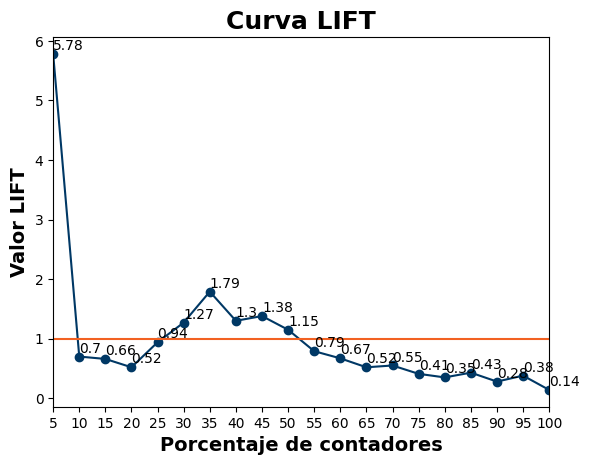

In [19]:
def plot_lift(y_true, proba, bins=20):
    df = pd.DataFrame({"y": y_true, "proba": proba})
    df = df.sort_values("proba", ascending=False).reset_index(drop=True)
    df["bucket"] = pd.qcut(df.index, bins, labels=False)

    lift_table = df.groupby("bucket").agg(
        n=("y","size"),
        frauds=("y","sum"),
        avg_score=("proba","mean")
    ).reset_index()

    lift_table["fraud_rate"] = lift_table["frauds"] / lift_table["n"]
    global_rate = df["y"].mean()
    lift_table["lift"] = lift_table["fraud_rate"] / global_rate
    lift_table["cum_frauds"] = lift_table["frauds"].cumsum()
    lift_table["cum_frauds_pct"] = lift_table["cum_frauds"] / df["y"].sum()

    plt.figure(figsize=(8,6))
    plt.plot(np.linspace(0,100,bins), lift_table["cum_frauds_pct"]*100, marker='o')
    plt.xlabel("% población (ordenada por score)")
    plt.ylabel("% fraudes capturados (acumulado)")
    plt.title("Curva Lift acumulada (modelo supervisado)")
    plt.grid(True)
    plt.show()

    return lift_table

lift_table = lift_chart_plot(y_eval, proba_cal_val, num_chunks=20)


In [20]:
y_pred = (y_proba >= thres_train).astype(int)

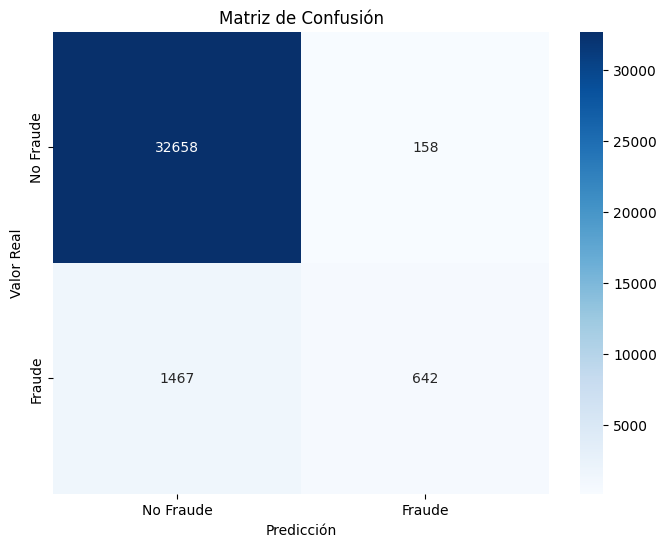


Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98     32816
         1.0       0.80      0.30      0.44      2109

    accuracy                           0.95     34925
   macro avg       0.88      0.65      0.71     34925
weighted avg       0.95      0.95      0.94     34925



In [21]:
cm = confusion_matrix(y, y_pred)
# Crear una visualización más clara
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fraude', 'Fraude'],
            yticklabels=['No Fraude', 'Fraude'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()
 
# También puedes mostrar el reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y, y_pred))

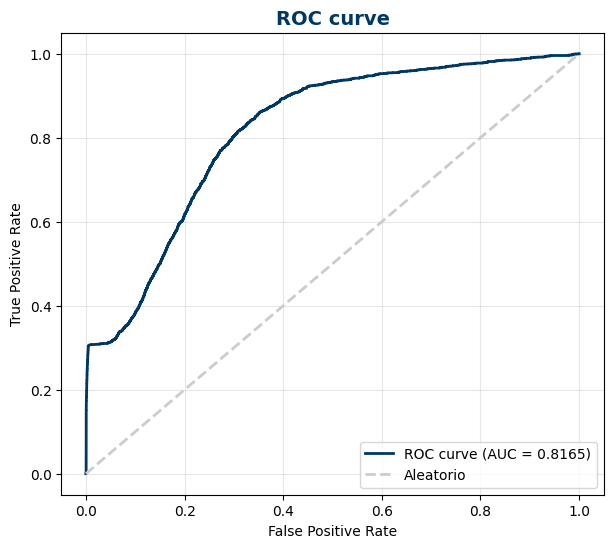

ROC AUC Score: 0.8165


In [22]:
fpr, tpr, thresholds = roc_curve(y, y_proba)
roc_auc = roc_auc_score(y, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# Estilo
plt.grid(alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve", fontsize=14, weight="bold", color=ufd_blue)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

Let's see also gain and lift curves

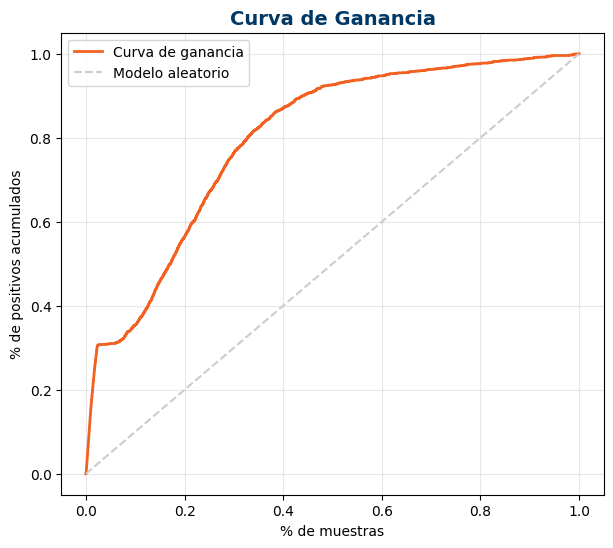

In [23]:
plot_gain(y, y_proba)

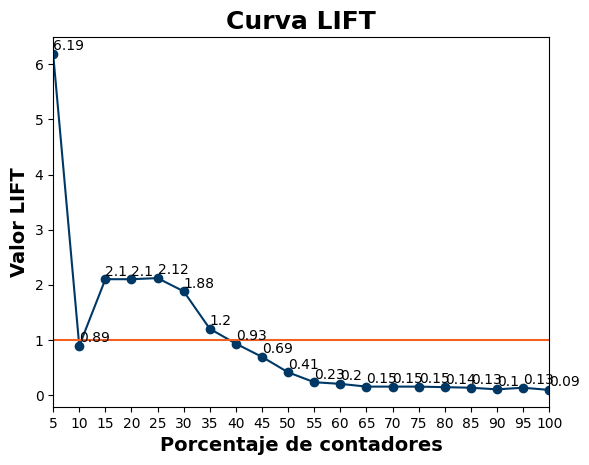

In [24]:
lift_chart_plot(y, y_proba, num_chunks=20)

In [25]:
final_df["target"].value_counts()

target
0.0    32816
1.0     2109
Name: count, dtype: int64

In [26]:
# # First, get the indices of the test set in final_df
# test_indices = X_test.index
# train_indices = X_train.index

# # Assign the predicted probabilities to the correct rows
# final_df.loc[test_indices, "xgb_pred_proba"] = y_proba
# final_df.loc[train_indices, "xgb_pred_proba"] = y_proba_train

# final_df.loc[test_indices, "train"] = 0
# final_df.loc[train_indices, "train"] = 1

In [27]:
final_df["pred_proba"] = y_proba

In [28]:
final_df["final_scoring"] = final_df["fraude_score_no_supervisado"]*0.3 + final_df["pred_proba"]*0.7

We define the cuts attending to the lift chart previously defined:

In [29]:
cuts = [25, 35]  
thresholds = get_probability_thresholds(y, y_proba, cuts)

print("Thresholds:", thresholds)

Thresholds: [0.1298482484761248, 0.07056375345312077]


We create the new cateogria_fraude column used to order the probabilistic results of the fraud

In [30]:
conditions = [
    final_df["final_scoring"] < thresholds[0],                             
    (final_df["final_scoring"] >= thresholds[0]) & (final_df["final_scoring"] < thresholds[1]),  
    final_df["final_scoring"] >= thresholds[1]                             
]

choices = ["Bajo", "Medio", "Alto"]

final_df["categoria_fraude"] = np.select(conditions, choices, default="Bajo")

### 5.2.4. Feature importance

In [31]:
coeficientes = model.coef_[0]
features = X.columns

df_importancia = pd.DataFrame({
    'feature': features,
    'coefficient': coeficientes,
    'abs_coefficient': np.abs(coeficientes) 
}).sort_values(by='abs_coefficient', ascending=False).reset_index(drop=True)

df_importancia.head(10)

,feature,coefficient,abs_coefficient
0,consumo_zero_anio_actual,0.000269,0.000269
1,consumo_max_anio_anterior,-0.000259,0.000259
2,consumo_max_anio_actual,-0.000248,0.000248
3,consumo_zero_anio_anterior,0.000240,0.000240
4,consumo_max_trimestre_anio_pasado,-0.000170,0.000170
5,consumo_max_trimestre_actual,-0.000170,0.000170
6,consumo_max_mes_anio_pasado,-0.000119,0.000119
7,consumo_max_mes_pasado,-0.000116,0.000116
8,consumo_max_mes_actual,-0.000115,0.000115
9,pct_change_semana_actual_vs_anio_pasado,-0.000091,0.000091


Let's save this data frame into the powerbi folder. We will use then this data to show it in the dashboard

In [32]:
df_importancia.head(10).to_csv(OUTPUT_FEATURE_IMPORTANCE_LOGREG, sep=";", decimal=",")

## 5.3. Evaluating the model

We are going to use the previously trained model to test it in the april data for example. Thus, let's go for it

In [33]:
for col in X:
    if col not in X_eval:
        X_eval[col] = 0

In [34]:
y_proba_eval = model.predict_proba(X_eval[X.columns])[:, 1] 
y_pred_eval = model.predict(X_eval[X.columns]) # threshold 0.5

In [35]:
final_df_eval["pred_proba"] = y_proba_eval
final_df_eval["final_scoring"] = final_df_eval["fraude_score_no_supervisado"]*0.3 + final_df_eval["pred_proba"]*0.7

In [36]:
thresholds_val = get_probability_thresholds(y_eval, final_df_eval["final_scoring"], cuts)

conditions_val = [
    final_df_eval["final_scoring"] < thresholds_val[0],                             
    (final_df_eval["final_scoring"] >= thresholds_val[0]) & (final_df_eval["final_scoring"] < thresholds_val[1]),  
    final_df_eval["final_scoring"] >= thresholds_val[1]                             
]

final_df_eval["categoria_fraude"] = np.select(conditions_val, choices, default="Bajo")

In [37]:
final_df_eval["categoria_fraude"].value_counts()

categoria_fraude
Bajo    27225
Alto     9075
Name: count, dtype: int64

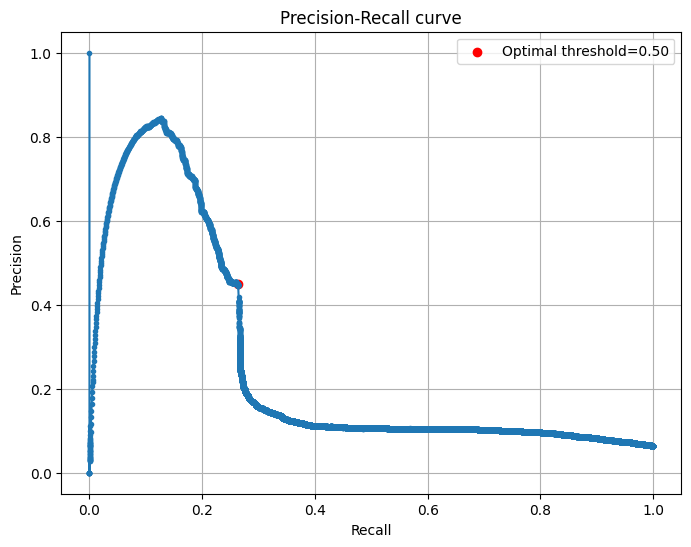

In [38]:
thres_val, _ = find_optimal_thres(y_eval, y_proba_eval)

Let's define the prediction array making use of the extracted threshold

In [39]:
y_pred_eval = (y_proba_eval >= thres_val).astype(int)
y_pred_eval = (y_proba_eval >= thres_train).astype(int)

In [40]:
thres_val

np.float64(0.5007157489695422)

If we show the confusion matrix:

In [41]:
model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 42,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

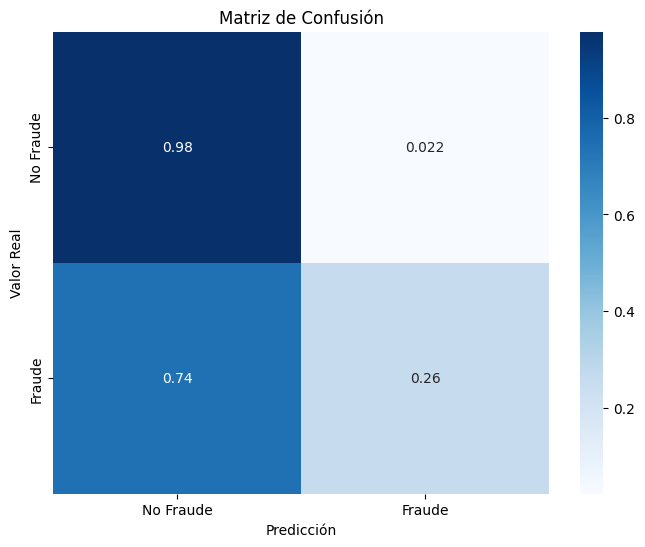


Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96     33999
         1.0       0.45      0.26      0.33      2301

    accuracy                           0.93     36300
   macro avg       0.70      0.62      0.65     36300
weighted avg       0.92      0.93      0.92     36300

0.3299422601044817


In [42]:
cm = confusion_matrix(y_eval, y_pred_eval, normalize="true")
# Crear una visualización más clara
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues',
            xticklabels=['No Fraude', 'Fraude'],
            yticklabels=['No Fraude', 'Fraude'], )
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()
 
# También puedes mostrar el reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y_eval, y_pred_eval))

print(f1_score(y_eval, y_pred_eval))

Primeramente pintaremos la curva ROC junto con su valor de AUC

In [43]:
2*(precision_score(y_eval, y_pred_eval)*recall_score(y_eval, y_pred_eval)) / (precision_score(y_eval, y_pred_eval)+recall_score(y_eval, y_pred_eval))

0.3299422601044817

In [44]:
precision_score(y_eval, y_pred_eval)

0.4491017964071856

In [45]:
recall_score(y_eval, y_pred_eval)

0.2607561929595828

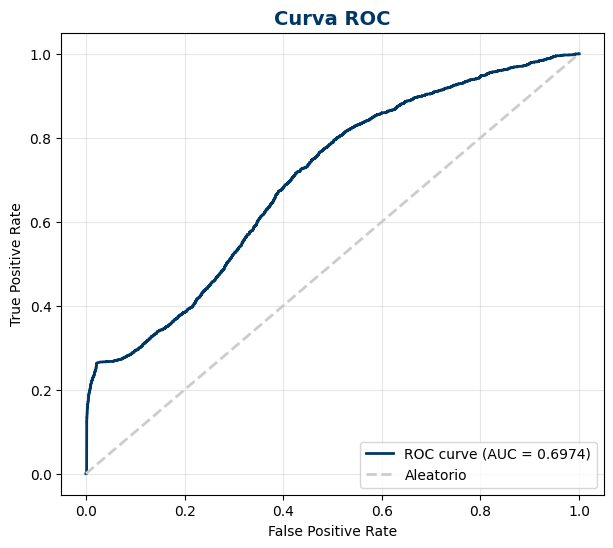

ROC AUC Score: 0.6974


In [46]:
fpr, tpr, thresholds = roc_curve(y_eval, y_proba_eval)
roc_auc_eval = roc_auc_score(y_eval, y_proba_eval)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc_eval:.4f})")
plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# Estilo
plt.grid(alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC", fontsize=14, weight="bold", color=ufd_blue)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print(f"ROC AUC Score: {roc_auc_eval:.4f}")

Mostramos también las curvas de ganancia y lift a continuación

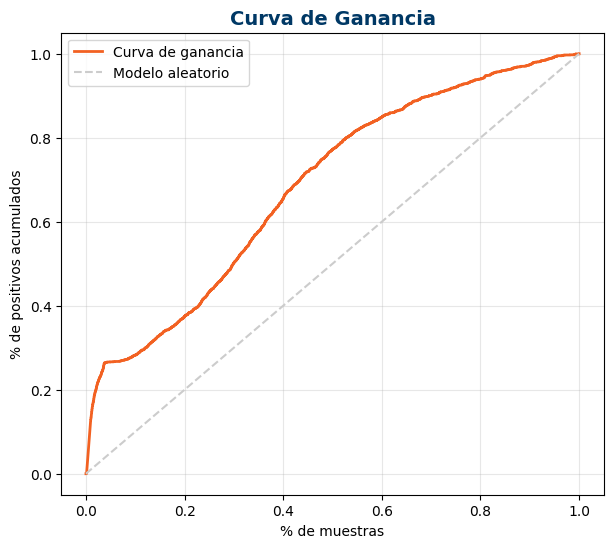

In [47]:
plot_gain(y_eval, y_proba_eval)

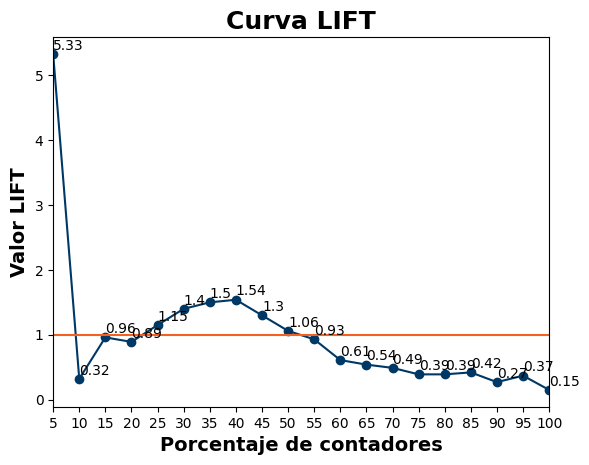

In [48]:
lift_chart_plot(y_eval, y_proba_eval, num_chunks=20)

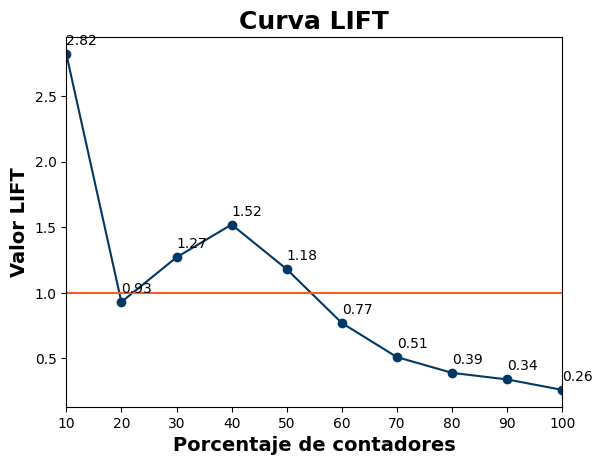

In [49]:
lift_chart_plot(y_eval, y_proba_eval, num_chunks=10)

## 5.4. Explainability

Let's make a global shap plot, in order to understand how the model gives predictions

In [50]:
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_eval)

# shap.summary_plot(shap_values, X_eval, max_display=15)

In [51]:
# df_shap_eval = final_df_eval[["cups_sgc", "cnt_id"]].join(X_eval, how="right")
# df_shap_eval.head(5)

In [52]:
# # Pasamos shap_values a DataFrame
# df_shap_local = pd.DataFrame(shap_values, columns=X_eval.columns)

# # Añadimos las predicciones y el identificador
# df_local_explain = pd.DataFrame({
#     "cups_sgc": df_shap_eval["cups_sgc"], 
#     "cnt_id": df_shap_eval["cnt_id"], 
#     "prediction": model.predict_proba(X_eval)[:,1]
# })

# # 3. Pasamos a formato largo (para Power BI)
# df_shap_long = df_shap_local.reset_index().melt(
#     id_vars="index",
#     var_name="feature",
#     value_name="shap_value"
# )

# # 4. Unimos con los identificadores y predicciones
# df_explain_final = df_shap_long.merge(
#     df_local_explain.reset_index(),
#     on="index"
# ).drop(columns=["index"])

# df_explain_final["abs_shap_value"] = df_explain_final["shap_value"].abs()
# # Esto lo exportas a CSV y lo cargas en Power BI
# df_explain_final.to_csv("../powerbi/shap_local_explain_xgb.csv", index=False, decimal=",", sep=";")


## 5.7. Dashboard data extraction